Training Monte Carlo Tic-Tac-Toe Agent...

Episode 1000 | Wins=773 Losses=139 Draws=88
Episode 2000 | Wins=835 Losses=95 Draws=70
Episode 3000 | Wins=863 Losses=80 Draws=57
Episode 4000 | Wins=894 Losses=60 Draws=46
Episode 5000 | Wins=908 Losses=37 Draws=55
Episode 6000 | Wins=918 Losses=40 Draws=42
Episode 7000 | Wins=924 Losses=43 Draws=33
Episode 8000 | Wins=934 Losses=33 Draws=33
Episode 9000 | Wins=920 Losses=41 Draws=39
Episode 10000 | Wins=930 Losses=41 Draws=29
Episode 11000 | Wins=927 Losses=32 Draws=41
Episode 12000 | Wins=934 Losses=33 Draws=33
Episode 13000 | Wins=928 Losses=30 Draws=42
Episode 14000 | Wins=946 Losses=31 Draws=23
Episode 15000 | Wins=925 Losses=38 Draws=37
Episode 16000 | Wins=938 Losses=28 Draws=34
Episode 17000 | Wins=942 Losses=25 Draws=33
Episode 18000 | Wins=954 Losses=28 Draws=18
Episode 19000 | Wins=945 Losses=27 Draws=28
Episode 20000 | Wins=952 Losses=32 Draws=16
Episode 21000 | Wins=948 Losses=24 Draws=28
Episode 22000 | Wins=949 Losses=33 Draws=

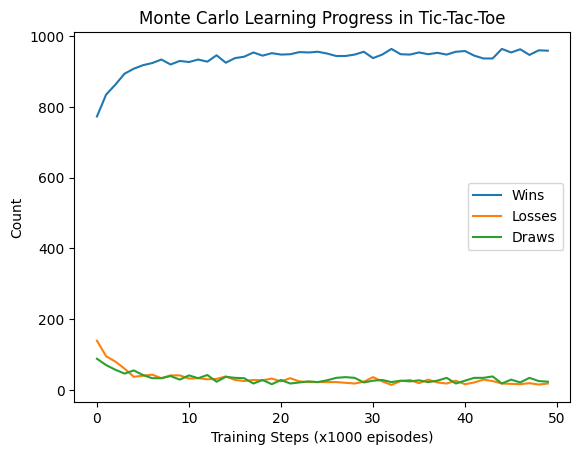

In [ ]:
# ==========================================================
# Monte Carlo Reinforcement Learning for Tic-Tac-Toe
# WITH VISUAL OUTPUT AND VISUALIZATION
#
# This program implements:
# 1. Monte Carlo First-Visit Control
# 2. Episodic learning via self-play
# 3. Policy improvement using epsilon-greedy strategy
# 4. Visualization of training performance
#
# Author: RL Teaching Version
# ==========================================================

import random
from collections import defaultdict
import matplotlib.pyplot as plt

# ------------------------------
# Environment Setup
# ------------------------------

# State representation:
# Board is represented as tuple of length 9:
# index positions:
#
# 0 | 1 | 2
# ---------
# 3 | 4 | 5
# ---------
# 6 | 7 | 8

EMPTY = 0       # empty cell
X = 1           # RL Agent (learning player)
O = -1          # Opponent (random policy)

# Reward definition (terminal rewards)
WIN_REWARD = 1
LOSS_REWARD = -1
DRAW_REWARD = 0

# Create initial empty board
def initial_board():
    # tuple used because it is hashable (needed for dictionary keys)
    return tuple([EMPTY]*9)

# Return list of available actions (empty positions)
def available_moves(state):
    return [i for i,v in enumerate(state) if v == EMPTY]

# Apply an action and return new state
def make_move(state, action, player):
    # convert tuple to list to modify
    s = list(state)
    s[action] = player
    return tuple(s)

# Check if game has reached terminal state
def check_winner(state):

    # All winning combinations
    wins = [(0,1,2),(3,4,5),(6,7,8),
            (0,3,6),(1,4,7),(2,5,8),
            (0,4,8),(2,4,6)]

    # Check sums
    for a,b,c in wins:
        total = state[a]+state[b]+state[c]
        if total == 3:
            return X      # Agent wins
        if total == -3:
            return O      # Opponent wins

    # If no empty spaces left -> draw
    if EMPTY not in state:
        return "DRAW"

    return None   # game continues

# ------------------------------
# Monte Carlo RL Storage
# ------------------------------

# Q(s,a) = expected return for taking action a in state s
Q = defaultdict(float)

# Stores all returns observed for (state,action)
# Used to compute average return (Monte Carlo estimate)
Returns = defaultdict(list)

# Exploration probability (epsilon-greedy)
epsilon = 0.1

# Statistics for visualization
win_list = []
loss_list = []
draw_list = []

# ------------------------------
# Policy: Epsilon-Greedy
# ------------------------------

def epsilon_greedy(state):

    actions = available_moves(state)

    # Exploration: choose random action with probability epsilon
    if random.random() < epsilon:
        return random.choice(actions)

    # Exploitation: choose best action according to learned Q-values
    qvals = [Q[(state,a)] for a in actions]
    max_q = max(qvals)

    # multiple actions may have same value
    best_actions = [a for a in actions if Q[(state,a)] == max_q]

    return random.choice(best_actions)

# ------------------------------
# Episode Simulation (Self-Play)
# ------------------------------

def play_episode():

    # Each episode is a full game from start to terminal state
    state = initial_board()

    # store visited (state,action) pairs
    episode = []

    while True:

        # ---- Agent Move ----
        action = epsilon_greedy(state)

        next_state = make_move(state, action, X)

        # Save experience
        episode.append((state, action))

        winner = check_winner(next_state)

        if winner:
            # Episode ends
            return episode, winner

        # ---- Opponent Move (random policy) ----
        opp_moves = available_moves(next_state)

        if not opp_moves:
            return episode, "DRAW"

        opp_action = random.choice(opp_moves)

        next_state = make_move(next_state, opp_action, O)

        winner = check_winner(next_state)

        if winner:
            return episode, winner

        # Continue game
        state = next_state

# ------------------------------
# Training using Monte Carlo
# ------------------------------

def train(episodes=50000):

    wins = 0
    losses = 0
    draws = 0

    # Loop over episodes
    for ep in range(episodes):

        # Generate full episode
        episode, result = play_episode()

        # Assign final return (G)
        if result == X:
            G = WIN_REWARD
            wins += 1
        elif result == O:
            G = LOSS_REWARD
            losses += 1
        else:
            G = DRAW_REWARD
            draws += 1

        # First-Visit Monte Carlo Update
        visited = set()

        for (state, action) in episode:

            if (state,action) not in visited:

                visited.add((state,action))

                # Store observed return
                Returns[(state,action)].append(G)

                # Update Q-value as average return
                Q[(state,action)] = sum(Returns[(state,action)]) / len(Returns[(state,action)])

        # Save statistics every 1000 episodes
        if (ep+1) % 1000 == 0:

            win_list.append(wins)
            loss_list.append(losses)
            draw_list.append(draws)

            print(f"Episode {ep+1} | Wins={wins} Losses={losses} Draws={draws}")

            wins = losses = draws = 0

# ------------------------------
# Visualization of Training Progress
# ------------------------------

def plot_results():

    plt.figure()

    plt.plot(win_list, label="Wins")
    plt.plot(loss_list, label="Losses")
    plt.plot(draw_list, label="Draws")

    plt.title("Monte Carlo Learning Progress in Tic-Tac-Toe")
    plt.xlabel("Training Steps (x1000 episodes)")
    plt.ylabel("Count")

    plt.legend()
    plt.show()

# ------------------------------
# Display Learned Policy (Opening Move)
# ------------------------------

def show_best_opening():

    state = initial_board()

    actions = available_moves(state)

    print("\nLearned Q-values for opening moves:")

    for a in actions:
        print("Position", a, "Q =", Q[(state,a)])

    best = max(actions, key=lambda
                a: Q[(state,a)])

    print("\nBest opening move learned:", best)

# ------------------------------
# Main Execution
# ------------------------------

if __name__ == "__main__":

    print("Training Monte Carlo Tic-Tac-Toe Agent...\n")

    train(50000)

    show_best_opening()

    plot_results()


In [ ]:
TASK:    Modify the existing Tic-Tac-Toe Reinforcement Learning implementation
to convert the current First-Visit Monte Carlo Control algorithm into
an Every-Visit Monte Carlo Control algorithm.